In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Descargar el archivo -> StudentsPerformance.csv
El archivo se puede descargar desde el siguiente enlace:
[Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)


In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Comprensión de variables (columnas)
Tamaño, nombres de columnas, tipos de datos y resumen general.

In [3]:
# Tamaño: filas y columnas
print("Filas y columnas:", df.shape)

Filas y columnas: (1000, 8)


In [4]:
# Nombres de columnas
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [5]:
 # Tipos de datos
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [6]:
# Resumen general - df.info() muestra un resumen completo de la estructura del DataFrame.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 3. Calidad de datos
Valores nulos, duplicados y valores atípicos.

In [7]:
# Valores nulos por columna
# df.isnull().sum() cuenta el número de valores faltantes (NaN) por cada columna.
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [8]:
# Cuenta el número total de filas duplicadas en el DataFrame.
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [9]:
# Valores atípicos en una variable numérica (ej. math score) usando rango intercuartílico (IQR)
Q1 = df["math score"].quantile(0.25)
Q3 = df["math score"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos = df[(df["math score"] < limite_inferior) | (df["math score"] > limite_superior)]
print(f"Limites: [{limite_inferior}, {limite_superior}]")
print("Cantidad de valores atipicos en math score:", atipicos.shape[0])
atipicos

Limites: [27.0, 107.0]
Cantidad de valores atipicos en math score: 8


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
145,female,group C,some college,free/reduced,none,22,39,33
338,female,group B,some high school,free/reduced,none,24,38,27
466,female,group D,associate's degree,free/reduced,none,26,31,38
787,female,group B,some college,standard,none,19,38,32
842,female,group B,high school,free/reduced,completed,23,44,36
980,female,group B,high school,free/reduced,none,8,24,23


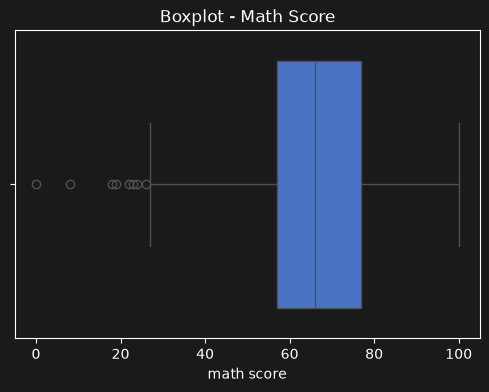

In [10]:
from matplotlib import pyplot as plt

# Visualización de atipicos con boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["math score"])
plt.title("Boxplot - Math Score")
plt.show()

## 4. Análisis exploratorio inicial

### 4.1 Variables categóricas (mínimo 2)

Frecuencias y porcentajes.


In [11]:
# gender
print(df["gender"].value_counts())
print()
print(df["gender"].value_counts(normalize=True) * 100)

gender
female    518
male      482
Name: count, dtype: int64

gender
female    51.8
male      48.2
Name: proportion, dtype: float64


In [12]:
# test preparation course
# Muestra cuantos estudiantes están en cada categoría
print(df["test preparation course"].value_counts())
print()
print(df["test preparation course"].value_counts(normalize=True) * 100)

test preparation course
none         642
completed    358
Name: count, dtype: int64

test preparation course
none         64.2
completed    35.8
Name: proportion, dtype: float64


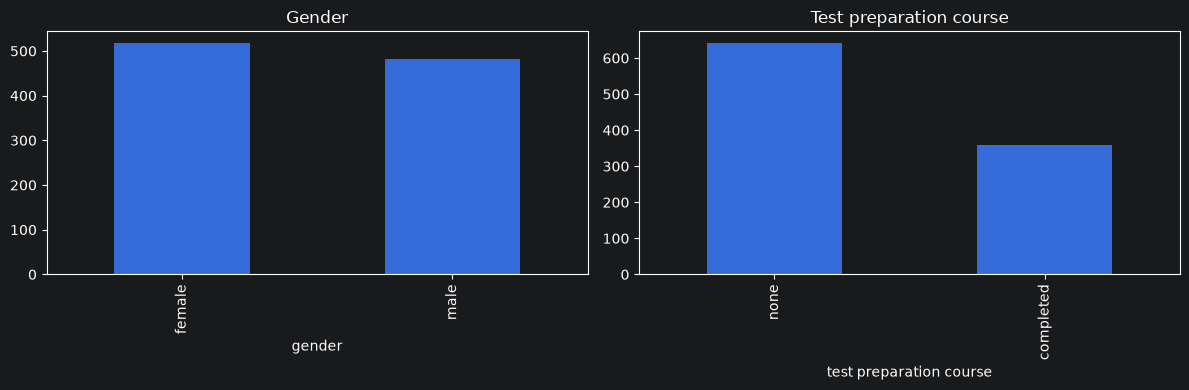

In [13]:
# Visualización rápida de las variables categóricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["gender"].value_counts().plot(kind="bar", ax=axes[0], title="Gender")
df["test preparation course"].value_counts().plot(kind="bar", ax=axes[1], title="Test preparation course")
plt.tight_layout()
plt.show()

### 4.2 Variables numéricas (mínimo 2)
Media, mediana, mínimo, máximo y desviación estándar.

In [14]:
df["math score"].describe()

count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64

In [15]:
df["reading score"].describe()

count    1000.000000
mean       69.169000
std        14.600192
min        17.000000
25%        59.000000
50%        70.000000
75%        79.000000
max       100.000000
Name: reading score, dtype: float64

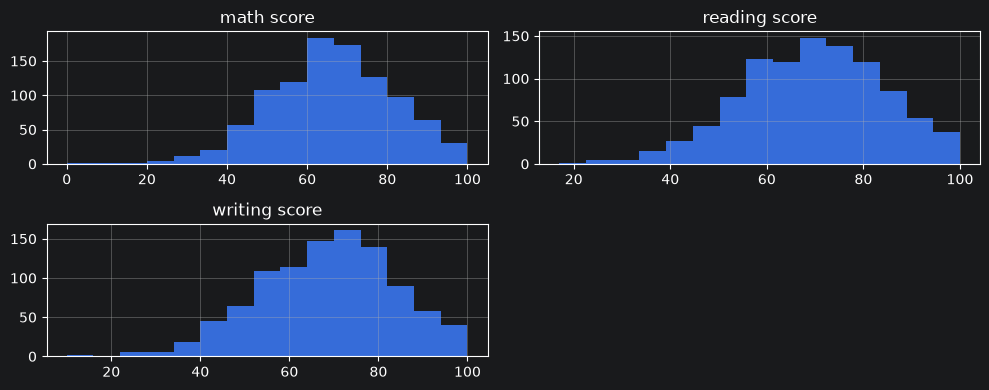

In [16]:
# Histogramas de las variables numericas
df[["math score", "reading score", "writing score"]].hist(figsize=(10, 4), bins=15)
plt.tight_layout()
plt.show()

## 5. Relación entre variables (para apoyar las preguntas del informe)

In [17]:
# Correlación entre las variables numéricas
df[["math score", "reading score", "writing score"]].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [18]:
# Relación entre preparación para el examen y puntaje de matemáticas
df.groupby("test preparation course")["math score"].mean()

test preparation course
completed    69.695531
none         64.077882
Name: math score, dtype: float64

In [19]:
# Relación entre nivel educativo de los padres y puntaje promedio
df["average score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)
df.groupby("parental level of education")["average score"].mean().sort_values(ascending=False)

parental level of education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average score, dtype: float64

## 6. Notas para el informe final
Usar los resultados anteriores para responder, en el documento Word/PDF, las 6 preguntas del anexo:
1. Que fenomeno representa el dataset.
2. Las 5 variables mas importantes y por que.
3. Hallazgos en la distribucion de variables categoricas y numericas.
4. Al menos 2 relaciones relevantes entre variables.
5. Problemas de calidad de datos detectados y como abordarlos.
6. Una pregunta de IA o problema predictivo a futuro (clasificacion, regresion, clustering).